In [3]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [5]:
# Step 1: Load Fashion MNIST Dataset
# --------------------------------------------------

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

# Fashion MNIST contains 10 classes
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape : (10000, 28, 28)


In [6]:
# Step 2: Preprocess the Images
# --------------------------------------------------

# Convert 28x28 images into 784-dimensional vectors
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Use a smaller subset for faster KNN experimentation
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

X_test_small = X_test[:2000]
y_test_small = y_test[:2000]

print("\nTraining samples used:", len(X_train_small))
print("Testing samples used :", len(X_test_small))



Training samples used: 10000
Testing samples used : 2000


In [7]:
# Step 3: Experiment with Different K Values
# --------------------------------------------------

k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:

    print("\nTraining KNN with K =", k)

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_small, y_train_small)

    y_pred = knn.predict(X_test_small)

    accuracy = accuracy_score(y_test_small, y_pred)

    accuracies.append(accuracy)

    print("Accuracy:", accuracy)


Training KNN with K = 1
Accuracy: 0.8075

Training KNN with K = 3
Accuracy: 0.8195

Training KNN with K = 5
Accuracy: 0.8225

Training KNN with K = 7
Accuracy: 0.826

Training KNN with K = 9
Accuracy: 0.822


In [8]:
# Step 4: Compare K Values
# --------------------------------------------------

print("\n===== K VALUE COMPARISON =====")

for k, accuracy in zip(k_values, accuracies):
    print("K =", k, "Accuracy =", accuracy)

# --------------------------------------------------
# Step 5: Find Best K
# --------------------------------------------------

best_index = np.argmax(accuracies)
best_k = k_values[best_index]

print("\nBest K:", best_k)
print("Best Accuracy:", accuracies[best_index])



===== K VALUE COMPARISON =====
K = 1 Accuracy = 0.8075
K = 3 Accuracy = 0.8195
K = 5 Accuracy = 0.8225
K = 7 Accuracy = 0.826
K = 9 Accuracy = 0.822

Best K: 7
Best Accuracy: 0.826


In [9]:
# Step 6: Classification Report for Best K
# --------------------------------------------------

best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_small, y_train_small)

best_predictions = best_knn.predict(X_test_small)

print("\n===== CLASSIFICATION REPORT =====")

print(classification_report(
    y_test_small,
    best_predictions,
    target_names=class_names
))



===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

 T-shirt/top       0.73      0.81      0.77       200
     Trouser       0.99      0.95      0.97       203
    Pullover       0.75      0.78      0.76       214
       Dress       0.86      0.85      0.85       190
        Coat       0.76      0.73      0.74       219
      Sandal       0.99      0.77      0.86       195
       Shirt       0.58      0.58      0.58       197
     Sneaker       0.84      0.94      0.89       200
         Bag       0.97      0.91      0.94       194
  Ankle boot       0.87      0.95      0.91       188

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



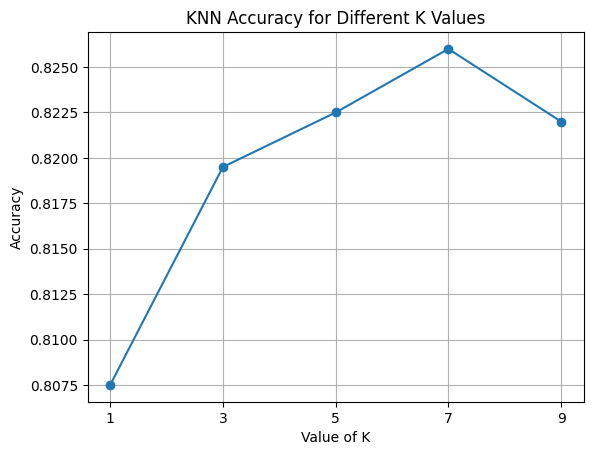

In [10]:
# Step 7: Plot Accuracy vs K
# --------------------------------------------------

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")

plt.xticks(k_values)
plt.grid()

plt.show()


Actual Class    : Coat
Predicted Class : Coat


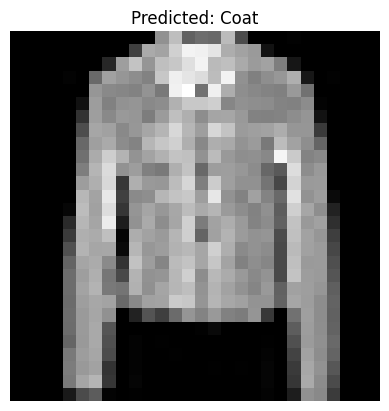

In [11]:
# Step 8: Test an Individual Image
# --------------------------------------------------

index = 10

prediction = best_knn.predict(
    X_test_small[index].reshape(1, -1)
)[0]

print("\nActual Class    :", class_names[y_test_small[index]])
print("Predicted Class :", class_names[prediction])

# Display image
plt.imshow(
    X_test_small[index].reshape(28, 28),
    cmap="gray"
)

plt.title("Predicted: " + class_names[prediction])
plt.axis("off")
plt.show()